# Appendix H.3 Second clinic only (only female students)

In [12]:
# Import libraries
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from process_improvement.charts.xmr_charts import xmr_chart
from process_improvement.charts.utils import XmRChartConfig

%matplotlib inline

## Step 1. Gather the data

In [13]:
# Get data
def get_data(dataset_url) -> pd.DataFrame:
    return pd.read_csv(dataset_url)

# Vienna url
rates_url = r'https://raw.githubusercontent.com/jimlehner/virus-of-variation-book/refs/heads/main/data/improvement-death-to-birth-rates.csv'
# Vienna General dataset url
rates_df = get_data(rates_url)

# Show first 10 lines of rates_df
rates_df.head(10)

# Show columns
rates_df.columns

Index(['Hospital', 'Stage', 'Year', 'Births', 'Deaths', 'Rate'], dtype='object')

### Drop  unnecessary columns from dataframe

In [14]:
rates_df = rates_df[[#'Hospital', 
                     'Stage', 
                     'Year', 
                     #'Births', 
                     #'Deaths', 
                     'Rate']]

# Make 'Value' column dtype string
rates_df['Year'] = rates_df['Year'].astype('string')

rates_df.head()

,Stage,Year,Rate
0,After pathological anatomy,1823,7.5
1,After pathological anatomy,1824,4.9
2,After pathological anatomy,1825,8.8
3,After pathological anatomy,1826,8.1
4,After pathological anatomy,1827,2.2


### Splite dataframe according to stage

In [15]:
baseline_df = rates_df[rates_df['Stage'] == 'After pathological anatomy'].copy()
first_clinic_df = rates_df[rates_df['Stage'] == 'Only first clinic'].reset_index(drop=True)
second_clinic_df = rates_df[rates_df['Stage'] == 'Only second clinic'].reset_index(drop=True)

## Step 2. Calculate the moving ranges

In [16]:
# Calculate the moving ranges for before_df
second_clinic_df['Moving Ranges'] = abs(second_clinic_df['Rate'].diff())
second_clinic_df

,Stage,Year,Rate,Moving Ranges
0,Only second clinic,1841,3.50,NaN
1,Only second clinic,1842,7.50,4.00
2,Only second clinic,1843,5.90,1.60
3,Only second clinic,1844,2.30,3.60
4,Only second clinic,1845,2.03,0.27
5,Only second clinic,1846,2.70,0.67


## Step 3. Calculate the average moving range

In [17]:
# Calculate the average moving range for before_df['Moving Ranges']
second_ave_mR = round(second_clinic_df['Moving Ranges'].mean(),2)
second_ave_mR

2.03

## Step 4. Calculate the mean

In [18]:
# Calculate the mean before_df['Rate']
second_mean = round(second_clinic_df['Rate'].mean(),2)
second_mean

3.99

## Step 5. Calculate the process limits

In [19]:
# Upper Process Limit (UPL)
second_UPL = round(second_mean + (2.660*second_ave_mR),2)
# Lower Process Limit (LPL)
second_LPL = round(second_mean - (2.660*second_ave_mR),2)
# Upper Process Limit (UPL)
second_URL = round(3.268*second_ave_mR,2)
# Show results
print('UPL:', second_UPL)
print('LPL:', second_LPL)
print('URL:', second_URL)

UPL: 9.39
LPL: -1.41
URL: 6.63


## Step 6. Put it all together

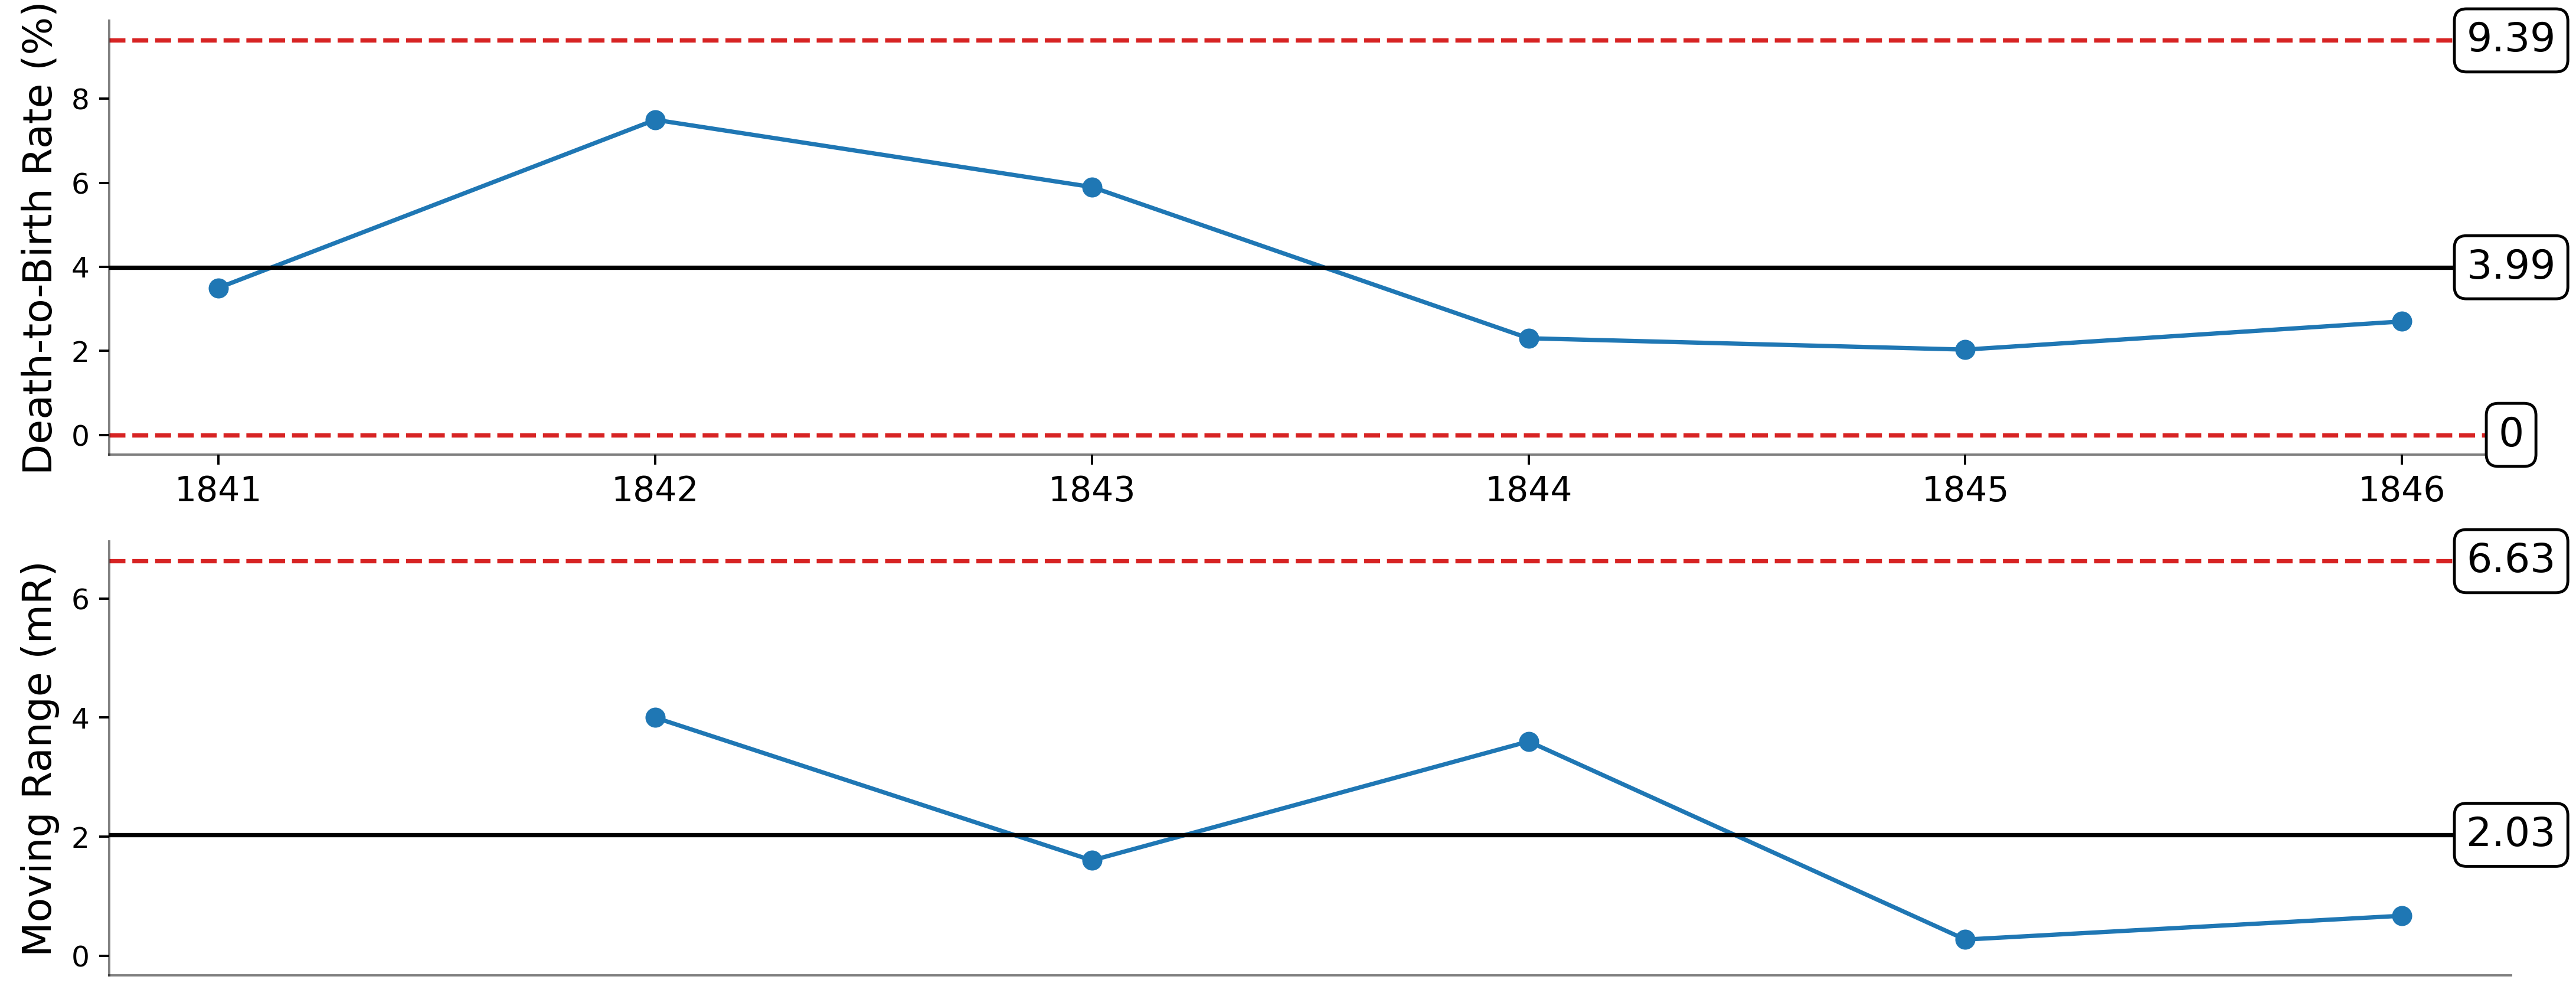

In [20]:
XmRConfig = XmRChartConfig(label_fontsize=14,
                          xtick_fontsize=12,
                          tickinterval=1,
                          xchart_ylabel="Death-to-Birth Rate (%)")

second_results = xmr_chart(second_clinic_df,
                           'Rate',
                           'Year', 
                           config=XmRConfig)

In [29]:
second_results.stats_df

,Chart,Process Stats,Values
0,X chart,Mean,3.99
1,X chart,UPL,9.39
2,X chart,LPL,0.0
3,X chart,PLR,10.8
4,mR chart,Ave. mR,2.03
5,mR chart,URL,6.63
6,,Characterization,Predictable
